In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import joblib

%matplotlib inline

NOTEBOOK_DIR     = Path('.').resolve()
PREPROCESSED_DIR = NOTEBOOK_DIR / 'preprocessed'
PROCESSED_DIR    = NOTEBOOK_DIR / 'processed'
PROCESSED_DIR.mkdir(exist_ok=True)

# shared features — only columns present in BOTH datasets
# co2_ppm and aqi exist in IoT but not in Blattmann, dropped below
FEATURES = ['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm']


In [2]:
iot   = pd.read_excel(PREPROCESSED_DIR / 'iot_preprocessed.xlsx')
blatt = pd.read_excel(PREPROCESSED_DIR / 'blattmann_preprocessed.xlsx')

print('IoT   shape:', iot.shape,   '| columns:', list(iot.columns))
print('Blatt shape:', blatt.shape, '| columns:', list(blatt.columns))


IoT   shape: (5080, 7) | columns: ['temperature', 'humidity', 'co2_ppm', 'tvoc_ppb', 'eco2_ppm', 'aqi', 'label']
Blatt shape: (55132, 5) | columns: ['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm', 'fire_alarm']


In [3]:
# drop co2_ppm and aqi — not available in Blattmann, cannot be shared features
DROP_IOT = [c for c in ['co2_ppm', 'aqi'] if c in iot.columns]
iot = iot.drop(columns=DROP_IOT)
print('Dropped from IoT:', DROP_IOT)

iot_label_map = {'Normal': 0, 'Cooking': 1}
iot['class_id'] = iot['label'].map(iot_label_map)

blatt['label']    = blatt['fire_alarm'].map({0: 'Normal', 1: 'Fire'})
blatt['class_id'] = blatt['fire_alarm'].map({0: 0, 1: 2})

print('IoT class_id  :', iot['class_id'].value_counts().to_dict())
print('Blatt class_id:', blatt['class_id'].value_counts().to_dict())


Dropped from IoT: ['co2_ppm', 'aqi']
IoT class_id  : {1: 4718, 0: 362}
Blatt class_id: {2: 40823, 0: 14309}


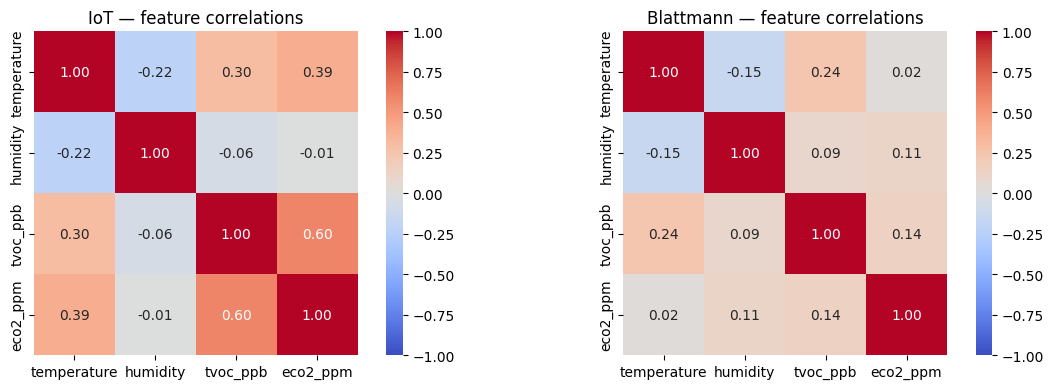

tvoc_ppb vs eco2_ppm Pearson r:
  IoT: 0.6005
  Blattmann: 0.1413
Decision: keep both — r < 0.95 and they carry different information across datasets.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, df) in zip(axes, [('IoT', iot), ('Blattmann', blatt)]):
    corr = df[FEATURES].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, ax=ax, square=True)
    ax.set_title(f'{name} — feature correlations')
plt.tight_layout()
plt.show()

print('tvoc_ppb vs eco2_ppm Pearson r:')
for name, df in [('IoT', iot), ('Blattmann', blatt)]:
    r = df[['tvoc_ppb','eco2_ppm']].corr().iloc[0,1]
    print(f'  {name}: {r:.4f}')
print('Decision: keep both — r < 0.95 and they carry different information across datasets.')


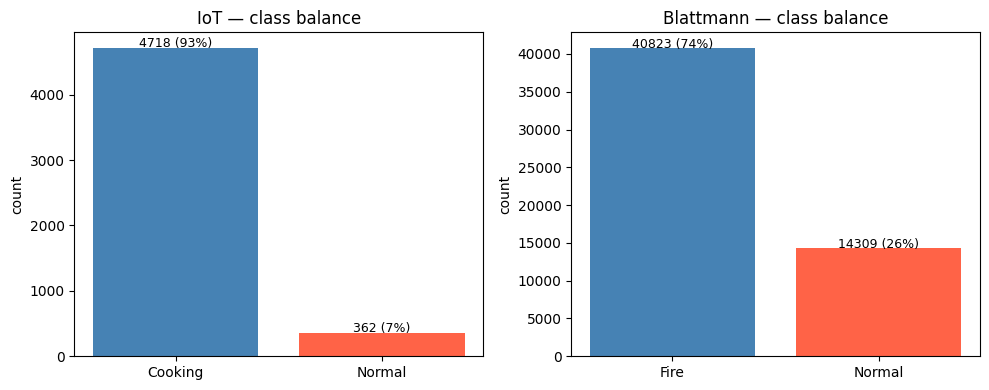

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, df) in zip(axes, [('IoT', iot), ('Blattmann', blatt)]):
    counts = df['label'].value_counts()
    colors = ['steelblue', 'tomato', 'gold']
    ax.bar(counts.index, counts.values, color=colors[:len(counts)])
    ax.set_title(f'{name} — class balance')
    ax.set_ylabel('count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, f'{v} ({v/len(df)*100:.0f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


In [6]:
X_iot   = iot[FEATURES].values
X_blatt = blatt[FEATURES].values

scaler = StandardScaler()
X_iot_sc   = scaler.fit_transform(X_iot)
X_blatt_sc = scaler.transform(X_blatt)

print('Scaler means :', dict(zip(FEATURES, scaler.mean_.round(2))))
print('Scaler stds  :', dict(zip(FEATURES, scaler.scale_.round(2))))

print('\nIoT scaled stats:')
print(pd.DataFrame(X_iot_sc, columns=FEATURES).describe().round(3))


Scaler means : {'temperature': np.float64(30.52), 'humidity': np.float64(46.2), 'tvoc_ppb': np.float64(313.64), 'eco2_ppm': np.float64(654.59)}
Scaler stds  : {'temperature': np.float64(4.38), 'humidity': np.float64(11.14), 'tvoc_ppb': np.float64(389.89), 'eco2_ppm': np.float64(172.54)}

IoT scaled stats:
       temperature  humidity  tvoc_ppb  eco2_ppm
count     5080.000  5080.000  5080.000  5080.000
mean         0.000     0.000     0.000    -0.000
std          1.000     1.000     1.000     1.000
min         -2.815    -2.173    -0.802    -3.267
25%         -0.782    -0.916    -0.525    -0.676
50%         -0.073     0.072    -0.291    -0.050
75%          0.793     0.790     0.196     0.594
max          1.846     2.406    14.610     8.064


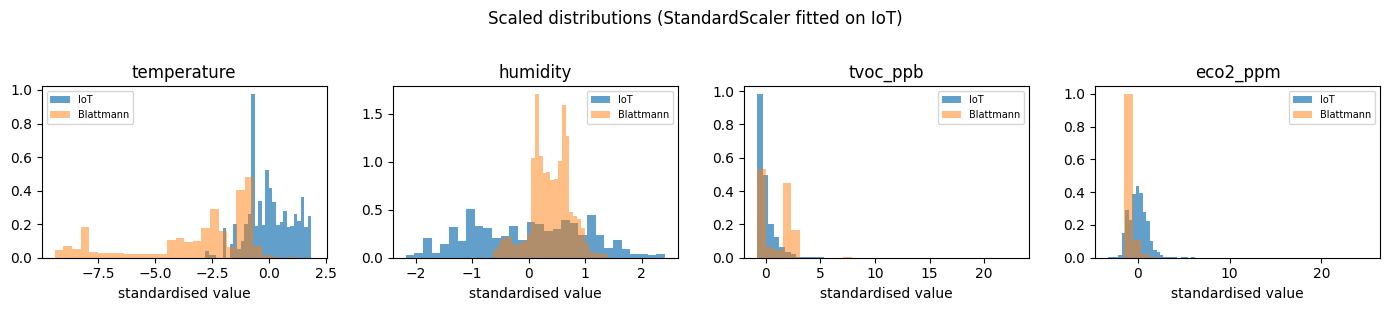

In [7]:
fig, axes = plt.subplots(1, len(FEATURES), figsize=(14, 3))
for ax, col in zip(axes, FEATURES):
    idx = FEATURES.index(col)
    ax.hist(X_iot_sc[:, idx],   bins=30, alpha=0.7, label='IoT',       density=True)
    ax.hist(X_blatt_sc[:, idx], bins=30, alpha=0.5, label='Blattmann', density=True)
    ax.set_title(col)
    ax.set_xlabel('standardised value')
    ax.legend(fontsize=7)
plt.suptitle('Scaled distributions (StandardScaler fitted on IoT)', y=1.02)
plt.tight_layout()
plt.show()


In [8]:
iot_out   = iot[FEATURES + ['label', 'class_id']].copy()
blatt_out = blatt[FEATURES + ['label', 'class_id']].copy()

iot_out.to_excel(PROCESSED_DIR / 'iot_processed.xlsx',        index=False)
blatt_out.to_excel(PROCESSED_DIR / 'blattmann_processed.xlsx', index=False)
joblib.dump(scaler, PROCESSED_DIR / 'scaler.joblib')

print('Saved processed/iot_processed.xlsx       :', iot_out.shape)
print('Saved processed/blattmann_processed.xlsx :', blatt_out.shape)
print('Saved processed/scaler.joblib')
print('\nIoT label distribution:')
print(iot_out['label'].value_counts())
print('\nBlattmann label distribution:')
print(blatt_out['label'].value_counts())


Saved processed/iot_processed.xlsx       : (5080, 6)
Saved processed/blattmann_processed.xlsx : (55132, 6)
Saved processed/scaler.joblib

IoT label distribution:
label
Cooking    4718
Normal      362
Name: count, dtype: int64

Blattmann label distribution:
label
Fire      40823
Normal    14309
Name: count, dtype: int64
